# ML project: Implied Volatility Surface Prediction 
### Bebiakina Anastasiia

The Black-Scholes-Merton formula gives a closed-form solution for the price of a
European option:

$$C = S \cdot N(d_1) - K e^{-rT} N(d_2)$$

where

$$d_1 = \frac{\ln(S/K) + (r + \frac{\sigma^2}{2})T}{\sigma\sqrt{T}}, \quad d_2 = d_1 - \sigma\sqrt{T}$$

The parameter $\sigma$ here is the **implied volatility (IV)** - the value
of volatility that reproduces the market price.
It is obtained by numerically inverting BS for each market quote. This inversion is computationally expensive and time-consuming when done for millions of options in real time.

This project aims to build a direct **ML surrogate** that maps **observable market
features** (moneyness, time-to-maturity, bid-ask spread) to the **implied
volatility**, therefore skipping the iterative inversion.


### Empirical observations BS cannot explain

- *Volatility smile / skew*: IV is not flat in strike; instead, OTM puts trade at
  higher IV than ATM options.
- *Term structure*: IV is highly dependent on the time-to-maturity.

These form the **IV surface** - a 2-D function of moneyness and
maturity that this ML model will learn to reproduce.


### Dataset

*SPY (S&P 500 ETF) daily EOD options, 2010–2023*.  

About 9.5M observations. 10 raw columns; more features (e.g. Greeks) will be computed below.  
*Source: https://www.kaggle.com/datasets/dudesurfin/spy-options-eod-volatility-surface-2010-2023*


In [2]:
# imports

import kagglehub  # database
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import norm
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error
import lightgbm as lgb
import optuna
import warnings
warnings.filterwarnings("ignore")

SEED = 42


In [3]:
# download latest version of dataset from KAGGLE

path = kagglehub.dataset_download("dudesurfin/spy-options-eod-volatility-surface-2010-2023")

# get all parquet files
parquet_files = [f for f in os.listdir(path)]

# create a single DataFrame
dfs = [pd.read_parquet(os.path.join(path, f)) for f in parquet_files]
df = pd.concat(dfs, ignore_index=True)

df


,QUOTE_DATE,EXPIRE_DATE,UNDERLYING_LAST,STRIKE,C_BID,C_ASK,C_IV,P_BID,P_ASK,P_IV
0,2023-01-03,2023-01-03,380.82,310.0,70.86,71.01,4.34673,0.00,0.01,1.21005
1,2023-01-03,2023-01-03,380.82,320.0,60.86,61.01,3.87219,0.00,0.01,0.99616
2,2023-01-03,2023-01-03,380.82,324.0,56.86,57.01,3.68261,0.00,0.01,0.91199
3,2023-01-03,2023-01-03,380.82,325.0,55.32,56.48,3.59852,0.00,0.01,0.89065
4,2023-01-03,2023-01-03,380.82,326.0,54.34,55.54,3.59029,0.00,0.01,0.87004
...,...,...,...,...,...,...,...,...,...,...
9468579,2019-12-31,2022-12-16,321.86,380.0,11.20,15.00,0.16437,65.01,69.94,0.00022
9468580,2019-12-31,2022-12-16,321.86,385.0,8.99,14.01,0.15998,68.00,73.00,-0.00015
9468581,2019-12-31,2022-12-16,321.86,390.0,8.00,12.44,0.15782,72.00,76.51,-0.00002
9468582,2019-12-31,2022-12-16,321.86,395.0,3.33,11.50,0.14405,75.60,80.51,0.00016


### Data Inspection & Cleaning

In [4]:
# parse dates & compute DTE (Days-to-Expiry) for the IV surface

# missing values 
missing = df.isnull().sum()
print("Missing values per column:")
print(missing[missing > 0] if missing.any() else "  → No missing values found")
print()

df["QUOTE_DATE"]  = pd.to_datetime(df["QUOTE_DATE"])
df["EXPIRE_DATE"] = pd.to_datetime(df["EXPIRE_DATE"])
df["DTE"] = (df["EXPIRE_DATE"] - df["QUOTE_DATE"]).dt.days

print("DTE description:")
print(df["DTE"].describe())
print(f"\nRows with DTE = 0 (expire the same day): {(df['DTE'] == 0).sum():,}")

df.describe().round(4)

Missing values per column:
C_BID     11721
C_ASK     11721
C_IV     588461
P_BID     11647
P_ASK     11647
P_IV     472386
dtype: int64

DTE description:
count    9.468584e+06
mean     1.751438e+02
std      2.157450e+02
min      0.000000e+00
25%      2.200000e+01
50%      8.500000e+01
75%      2.560000e+02
max      1.096000e+03
Name: DTE, dtype: float64

Rows with DTE = 0 (expire the same day): 176,519


,QUOTE_DATE,EXPIRE_DATE,UNDERLYING_LAST,STRIKE,C_BID,C_ASK,C_IV,P_BID,P_ASK,P_IV,DTE
count,9468584,9468584,9.468584e+06,9.468584e+06,9.456863e+06,9.456863e+06,8.880123e+06,9.456937e+06,9.456937e+06,8.996198e+06,9.468584e+06
mean,2018-11-20 21:19:02.667159040,2019-05-15 00:46:02.977862400,3.033093e+02,2.836159e+02,4.074040e+01,4.177310e+01,3.333000e-01,2.115630e+01,2.220660e+01,2.921000e-01,1.751438e+02
min,2010-01-04 00:00:00,2010-01-15 00:00:00,1.022500e+02,5.000000e+00,0.000000e+00,0.000000e+00,-5.000000e-04,0.000000e+00,0.000000e+00,-5.000000e-04,0.000000e+00
25%,2016-05-20 00:00:00,2016-12-16 00:00:00,2.109700e+02,1.850000e+02,1.650000e+00,1.890000e+00,1.589000e-01,5.000000e-01,5.400000e-01,1.593000e-01,2.200000e+01
50%,2019-10-22 00:00:00,2020-04-03 00:00:00,2.923200e+02,2.720000e+02,1.950000e+01,2.002000e+01,2.206000e-01,5.640000e+00,5.900000e+00,2.316000e-01,8.500000e+01
75%,2021-10-22 00:00:00,2022-03-18 00:00:00,4.047300e+02,3.790000e+02,5.700000e+01,5.796000e+01,3.314000e-01,2.399000e+01,2.480000e+01,3.408000e-01,2.560000e+02
max,2023-12-29 00:00:00,2026-12-18 00:00:00,4.777700e+02,6.400000e+03,4.454100e+02,2.000010e+05,5.576920e+01,4.451190e+03,2.000010e+05,2.411680e+01,1.096000e+03
std,NaN,NaN,1.049301e+02,1.298237e+02,5.446050e+01,2.584484e+02,5.052000e-01,3.860970e+01,3.079777e+02,2.997000e-01,2.157450e+02


**Cleaning rules**

Remove observations that are financially meaningless and/or numerically uninformative:

- `C_IV <= 0` IV must be strictly positive (as a standard deviation)
- `C_IV > 5` remove extreme values (>300%) 
- `C_BID <= 0` or `C_ASK <= 0` not tradeable market quote
- `C_ASK < C_BID` cleared market
- `DTE <= 0` expired at the sameday; Black-Scholes is undefined at $T=0$ 
- `UNDERLYING_LAST <= 0` or `STRIKE <= 0` must be positive for log-moneyness 


In [5]:
# first of all, remove rows with missing IV 

df_clean = df.dropna(subset=['C_IV', 'P_IV'])

n_before = len(df)

# mask restrictions
mask = (
    (df["C_IV"]  >  0.0)  &
    (df["C_IV"]  <  5.0)  &
    (df["C_BID"] >  0.0)  &
    (df["C_ASK"] >  0.0)  &
    (df["C_ASK"] >= df["C_BID"])  &
    (df["DTE"]   >  0)    &
    (df["UNDERLYING_LAST"] >  0.0)  &
    (df["STRIKE"]          >  0.0)
)

df_clean = df_clean[mask]
n_after = len(df_clean)

print(f"Rows before cleaning: {n_before}")
print(f"Rows after cleaning: {n_after}")
print(f"Removed: {n_before - n_after}  ({(n_before-n_after)/n_before:.1%})")


Rows before cleaning: 9468584
Rows after cleaning: 7761471
Removed: 1707113  (18.0%)


## Data Analysis

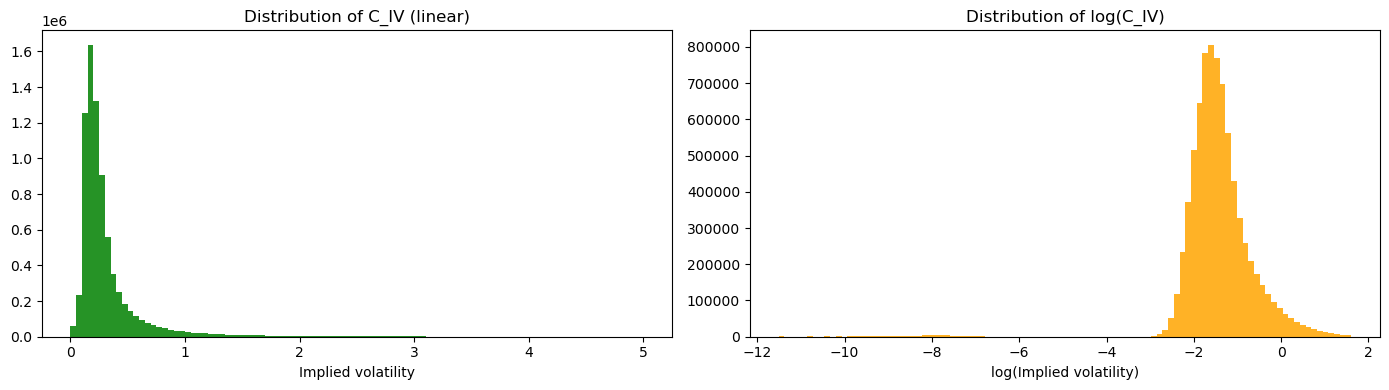

Median C_IV: 0.2243
Mean C_IV  : 0.3247
A heavy right tail is present: OTM options near expiry can have very high IV
Distribution of C_IV has log-normal shape. Therefore, consider log(IV) as the prediction target


In [6]:
# target distribution: C_IV 

# plot both linear and log values

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_clean["C_IV"], bins=100, color="green", alpha=0.85)
axes[0].set_title("Distribution of C_IV (linear)", fontsize=12)
axes[0].set_xlabel("Implied volatility")

axes[1].hist(np.log(df_clean["C_IV"]), bins=100, color="orange", alpha=0.85)
axes[1].set_title("Distribution of log(C_IV)", fontsize=12)
axes[1].set_xlabel("log(Implied volatility)")

plt.tight_layout()
plt.show()

print(f"Median C_IV: {df_clean['C_IV'].median():.4f}")
print(f"Mean C_IV  : {df_clean['C_IV'].mean():.4f}")

print("A heavy right tail is present: OTM options near expiry can have very high IV")
print("Distribution of C_IV has log-normal shape. Therefore, consider log(IV) as the prediction target")

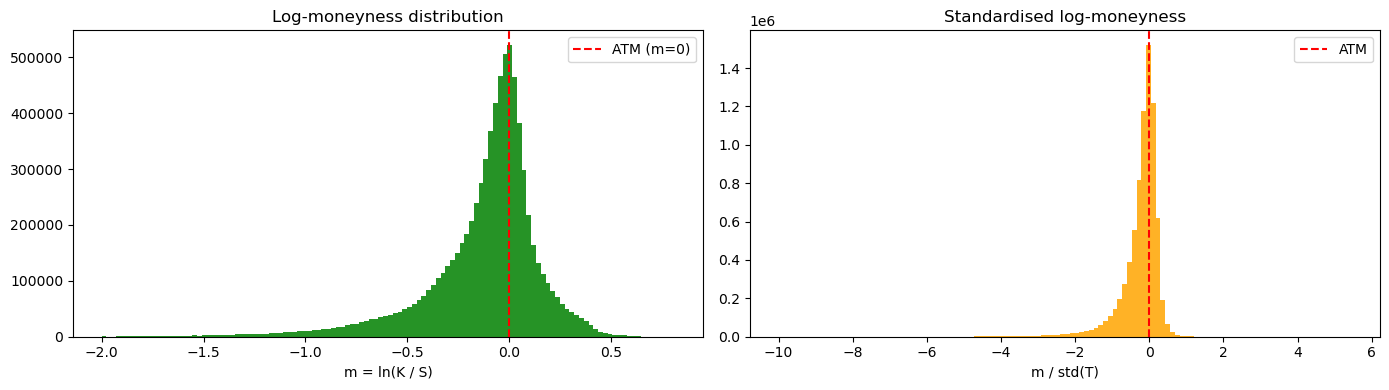

In [7]:
# Log-moneyness

# Log-moneyness: m = ln(K / S) ; symmetric around 0 (ATM), negative for ITM calls and positive for OTM calls.

# Standardised log-moneyness: m_std = m / sqrt(T) - account for different maturities


df_clean["log_moneyness"] = np.log(df_clean["STRIKE"] / df_clean["UNDERLYING_LAST"])
df_clean["T_years"] = df_clean["DTE"] / 252  
df_clean["sqrt_T"]  = np.sqrt(df_clean["T_years"])

# Standardised log-moneyness 
df_clean["m_std"] = df_clean["log_moneyness"] / (df_clean["sqrt_T"] + 1e-8)

# plotting 

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

axes[0].hist(df_clean["log_moneyness"].clip(-2,2), bins=120, color="green", alpha=0.85)
axes[0].axvline(0, color="red", linestyle="--", label="ATM (m=0)")
axes[0].set_title("Log-moneyness distribution", fontsize=12)
axes[0].set_xlabel("m = ln(K / S)"); axes[0].legend()

axes[1].hist(df_clean["m_std"].clip(-10,10), bins=120, color="orange", alpha=0.85)
axes[1].axvline(0, color="red", linestyle="--", label="ATM")
axes[1].set_title("Standardised log-moneyness", fontsize=12)
axes[1].set_xlabel("m / std(T)"); axes[1].legend()

plt.tight_layout(); plt.show()


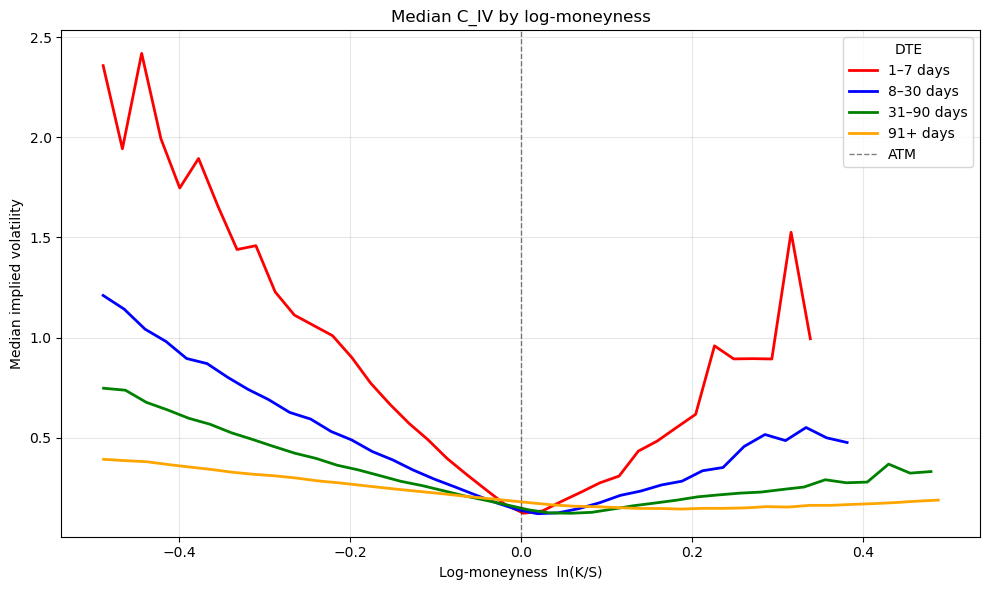

Observation: the pronounced left skew, higher IV for negative moneyness
Volatility smile -> linear models cannot capture this structure without polynomial / interaction terms


In [8]:
# Empitical volatility smile 

# OTM puts (m < 0) correspond to higher IV than ATM options (not constant)

# plot IV against log-moneyness

# smaller sample to avoid overplotting
df_sample = df_clean.sample(n=200_000, random_state=SEED)

# DTE buckets (calendar days)
dte_buckets = {
    "1–7 days"  : (1,  7),
    "8–30 days" : (8,  30),
    "31–90 days": (31, 90),
    "91+ days"  : (91, 9999),
}
colors = ["red", "blue", "green", "orange"]

fig, ax = plt.subplots(figsize=(10, 6))

# graphics 

i = 0
for label, (lo, hi) in dte_buckets.items():
    color = colors[i]
    subset = df_sample[(df_sample["DTE"] >= lo) & (df_sample["DTE"] <= hi)]
    subset = subset[(subset["log_moneyness"] >= -0.5) & (subset["log_moneyness"] <= 0.5)]
    bins = pd.cut(subset["log_moneyness"], bins=40)
    smile = subset.groupby(bins, observed=False)["C_IV"].median()
    midpoints = [interval.mid for interval in smile.index]
    ax.plot(midpoints, smile.values, color=color, linewidth=2, label=label)
    i += 1

ax.axvline(0, color="black", lw=1, linestyle="--", alpha=0.5, label="ATM")
ax.set_title("Median C_IV by log-moneyness", fontsize=12)
ax.set_xlabel("Log-moneyness  ln(K/S)")
ax.set_ylabel("Median implied volatility")
ax.legend(title="DTE"); ax.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("Observation: the pronounced left skew, higher IV for negative moneyness")
print("Volatility smile -> linear models cannot capture this structure without polynomial / interaction terms")


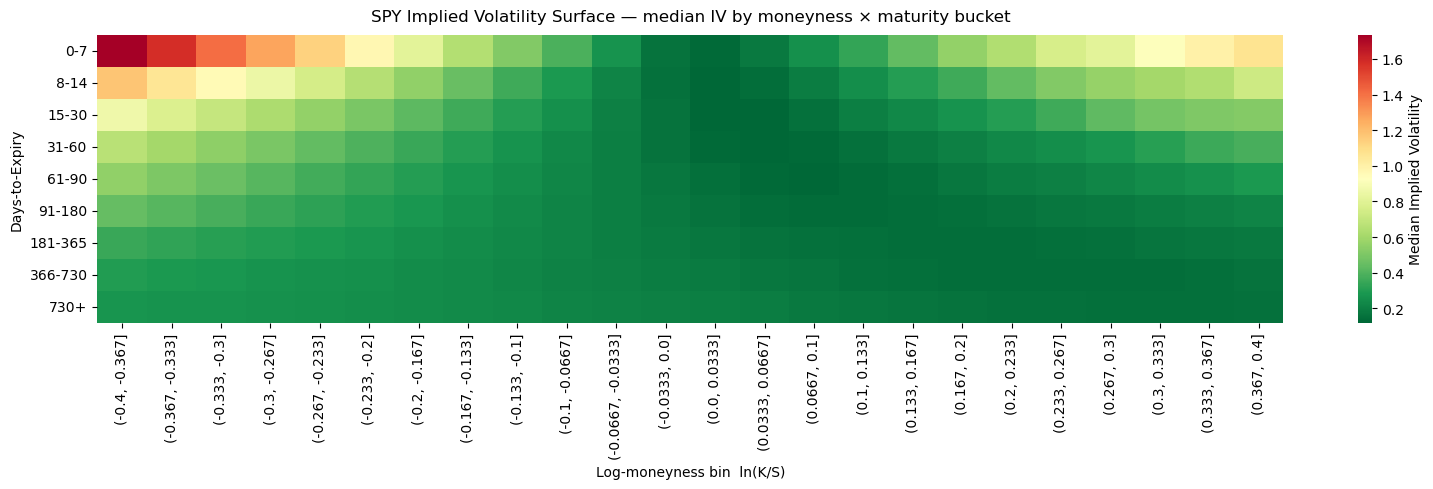

In [9]:
# IV Surface (moneyness x maturity) 

# bin dimensions
m_bins   = np.linspace(-0.4, 0.4, 25)   
dte_bins = [0, 7, 14, 30, 60, 90, 180, 365, 730, 9999]
dte_labels = ["0-7", "8-14", "15-30", "31-60", "61-90", "91-180", "181-365", "366-730", "730+"]

df_surf = df_clean.copy()
df_surf["m_bin"]   = pd.cut(df_surf["log_moneyness"], bins=m_bins)
df_surf["dte_bin"] = pd.cut(df_surf["DTE"], bins=dte_bins, labels=dte_labels)

surface = (
    df_surf
    .groupby(["dte_bin", "m_bin"], observed=False)["C_IV"]
    .median()
    .unstack("m_bin")
)

fig, ax = plt.subplots(figsize=(16, 5))
sns.heatmap(
    surface,
    ax=ax,
    cmap="RdYlGn_r",
    cbar_kws={"label": "Median Implied Volatility"},
    linewidths=0,
    yticklabels=True,
)
ax.set_title("SPY Implied Volatility Surface — median IV by moneyness × maturity bucket",
             fontsize=12, pad=10)
ax.set_xlabel("Log-moneyness bin  ln(K/S)")
ax.set_ylabel("Days-to-Expiry")
plt.tight_layout(); plt.show()


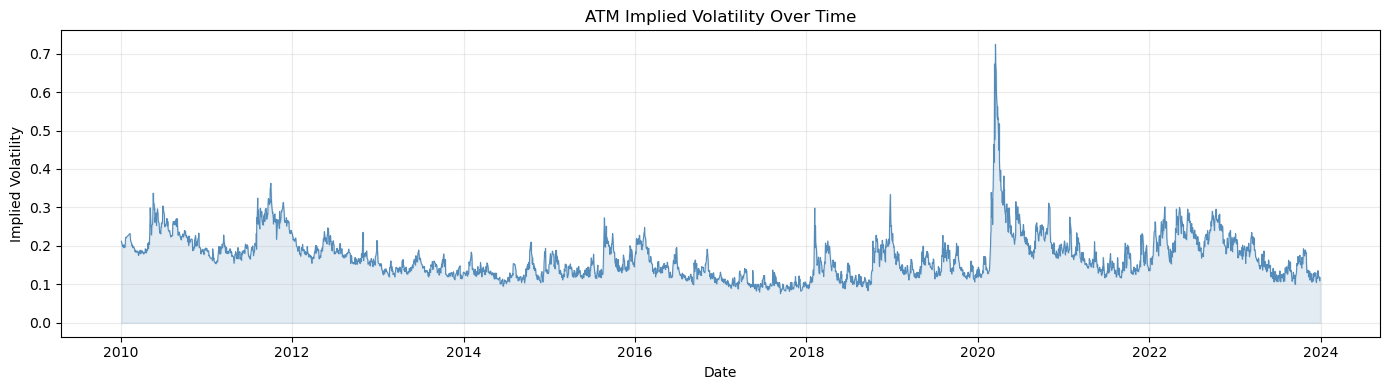

In [10]:
# analyze implied volarility over time; it is not stationary

# therefore, required to use a time-based split between train & test samples

atm_iv = (
    df_clean[df_clean["log_moneyness"].abs() < 0.02]   # near-ATM options only
    .groupby("QUOTE_DATE")["C_IV"]
    .median()
    .sort_index()
)

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(atm_iv.index, atm_iv.values, lw=0.8, color="steelblue", alpha=0.9)
ax.fill_between(atm_iv.index, atm_iv.values, alpha=0.15, color="steelblue")
ax.set_title("ATM Implied Volatility Over Time",
             fontsize=12)
ax.set_ylabel("Implied Volatility"); ax.set_xlabel("Date")
ax.grid(alpha=0.25)


plt.tight_layout(); plt.show()


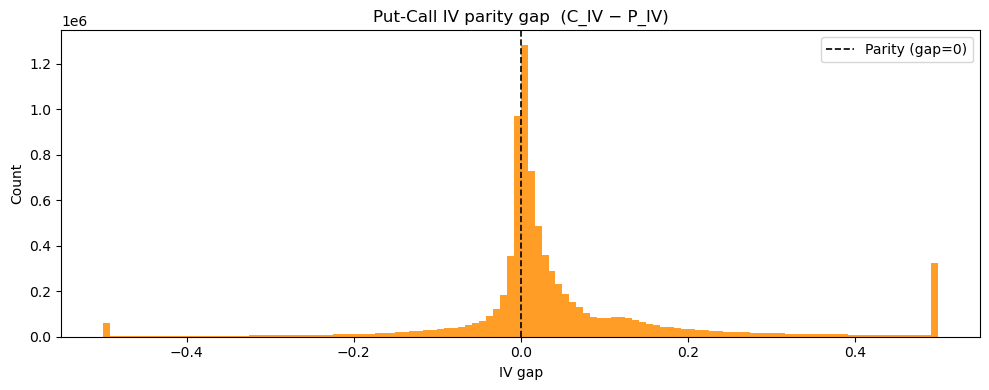

Mean IV gap : 0.0698
Std  IV gap : 0.3352


In [11]:
# Put-Call IV parity gap

# Put-call parity: a European call and put with the same K & T should imply the same volatility
# the gap  C_IV − P_IV  should be near zero for well-priced options

# Only meaningful where IV > 0
pcp = df[(df["P_IV"] > 0) & (df["P_IV"] < 5)].copy()
pcp["IV_gap"] = pcp["C_IV"] - pcp["P_IV"]

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pcp["IV_gap"].clip(-0.5, 0.5), bins=120,
        color="darkorange", edgecolor="none", alpha=0.85)
ax.axvline(0, color="black", lw=1.2, linestyle="--", label="Parity (gap=0)")
ax.set_title("Put-Call IV parity gap  (C_IV − P_IV)", fontsize=12)
ax.set_xlabel("IV gap"); ax.set_ylabel("Count"); ax.legend()
plt.tight_layout(); plt.show()

print(f"Mean IV gap : {pcp['IV_gap'].mean():.4f}")
print(f"Std  IV gap : {pcp['IV_gap'].std():.4f}")


## Feature Engineering

Main inputs from the *the Black-Scholes formula*:

- Log-moneyness: $m = \ln(K/S)$
- Time-to-expiry (years): `DTE` ÷ 252

Engineered *non-linear features*:

- `C_mid`: bid-ask spread (liquidity)
- `C_RBAS`: relative bid-ask spread (liquidity)
- `IV_gap`: put-call IV parity deviation
- $m^2$: captures the convexity of the smile
- $m^3$: aptures the skew asymmetry
- $m / \sqrt{T}$: standardised moneyness (consideres diffrences in maturities)
- $m^2 / T$: second-order term 
- $1/T$: captures the IV rise when close to expiry date
- $\sqrt{T}$: standard deviation of Brownian motion 


In [12]:
df_clean 


,QUOTE_DATE,EXPIRE_DATE,UNDERLYING_LAST,STRIKE,C_BID,C_ASK,C_IV,P_BID,P_ASK,P_IV,DTE,log_moneyness,T_years,sqrt_T,m_std
122,2023-01-03,2023-01-04,380.82,310.0,70.74,71.17,1.83944,0.00,0.01,0.93551,1,-0.205755,0.003968,0.062994,-3.266251
123,2023-01-03,2023-01-04,380.82,320.0,60.75,61.17,1.56727,0.00,0.01,0.79875,1,-0.174006,0.003968,0.062994,-2.762256
124,2023-01-03,2023-01-04,380.82,324.0,56.75,57.17,1.46227,0.00,0.01,0.74470,1,-0.161583,0.003968,0.062994,-2.565055
125,2023-01-03,2023-01-04,380.82,325.0,55.75,56.17,1.43738,0.00,0.01,0.73144,1,-0.158502,0.003968,0.062994,-2.516135
126,2023-01-03,2023-01-04,380.82,326.0,54.75,55.17,1.41135,0.00,0.01,0.71808,1,-0.155429,0.003968,0.062994,-2.467365
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9468579,2019-12-31,2022-12-16,321.86,380.0,11.20,15.00,0.16437,65.01,69.94,0.00022,1081,0.166055,4.289683,2.071155,0.080175
9468580,2019-12-31,2022-12-16,321.86,385.0,8.99,14.01,0.15998,68.00,73.00,-0.00015,1081,0.179127,4.289683,2.071155,0.086486
9468581,2019-12-31,2022-12-16,321.86,390.0,8.00,12.44,0.15782,72.00,76.51,-0.00002,1081,0.192030,4.289683,2.071155,0.092716
9468582,2019-12-31,2022-12-16,321.86,395.0,3.33,11.50,0.14405,75.60,80.51,0.00016,1081,0.204769,4.289683,2.071155,0.098867


In [13]:
# compute all remaining engineered features 

# for division by zero with small epsilon
EPS = 1e-8

df_clean["C_mid"]  = (df_clean["C_BID"] + df_clean["C_ASK"]) / 2
df_clean["C_RBAS"] = (df_clean["C_ASK"] - df_clean["C_BID"]) / (df_clean["C_mid"])

df_clean["inv_T"] = 1.0 / (df_clean["T_years"] + EPS)

df_clean["m2"] = df_clean["log_moneyness"] ** 2
df_clean["m3"] = df_clean["log_moneyness"] ** 3
df_clean["m2_over_T"] = df_clean["m2"] / (df_clean["T_years"] + EPS)
df_clean["m_sqrt_T"] = df_clean["log_moneyness"] * df_clean["sqrt_T"]

df_clean["IV_gap"] = np.where(
    (df_clean["P_IV"] > 0) & (df_clean["P_IV"] < 5),
    df_clean["C_IV"] - df_clean["P_IV"],
    0.0
)

FEATURE_COLS = [
    "log_moneyness",
    "m_std",           
    "m2",             
    "m3",
    "m2_over_T",
    "m_sqrt_T",
    "T_years",
    "sqrt_T",
    "inv_T",
    "C_RBAS",
    "IV_gap",
]
TARGET_COL = "C_IV"

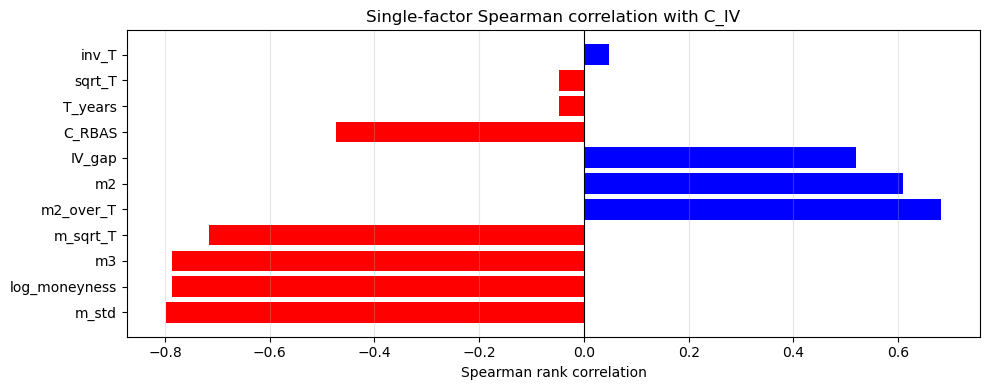

m_std           -0.7986
log_moneyness   -0.7874
m3              -0.7874
m_sqrt_T        -0.7166
m2_over_T        0.6821
m2               0.6091
IV_gap           0.5188
C_RBAS          -0.4727
T_years         -0.0470
sqrt_T          -0.0470
inv_T            0.0470


In [14]:
# single-factor analysis: Spearman rank correlation 

# Spearman correlation measures monotonic relationship without assuming linearity
# detect features with higher correlation

sample_corr = df_clean[FEATURE_COLS + [TARGET_COL]].sample(200_000, random_state=SEED)
spearman_vec = (
    sample_corr
    .corr(method="spearman")[TARGET_COL]
    .drop(TARGET_COL)
    .sort_values(key=abs, ascending=False)
)

fig, ax = plt.subplots(figsize=(10, 4))
colors_bar = ["red" if v < 0 else "blue" for v in spearman_vec.values]
ax.barh(spearman_vec.index, spearman_vec.values, color=colors_bar, edgecolor="none")
ax.axvline(0, color="black", lw=0.8)
ax.set_title("Single-factor Spearman correlation with C_IV", fontsize=12)
ax.set_xlabel("Spearman rank correlation")
ax.grid(axis="x", alpha=0.3)
plt.tight_layout(); plt.show()

print(spearman_vec.round(4).to_string())


### Train / Test split

*Purged walk-forward*: cut the dataset at a fixed date.  Everything before the cut is training data; everything after is test data.  

For cross-validation use `GroupKFold` with `groups = QUOTE_DATE` 

In [15]:
# chronological 80/20 split

df_clean = df_clean.sort_values("QUOTE_DATE").reset_index(drop=True)

all_dates = df_clean["QUOTE_DATE"].unique()
cutoff = pd.Series(all_dates).quantile(0.80)
print(f"Train up to {cutoff.date()}")

train_mask = df_clean["QUOTE_DATE"] <= cutoff
test_mask  = df_clean["QUOTE_DATE"] >  cutoff

X_all = df_clean[FEATURE_COLS]
y_all = df_clean[TARGET_COL]
groups = df_clean["QUOTE_DATE"]

X_train = X_all[train_mask].reset_index(drop=True)
y_train = y_all[train_mask].reset_index(drop=True)
X_test  = X_all[test_mask].reset_index(drop=True)
y_test  = y_all[test_mask].reset_index(drop=True)
g_train = groups[train_mask].reset_index(drop=True) 

Train up to 2021-03-26


In [16]:
# GroupKFold cross-validator

CV = GroupKFold(n_splits=5)

def cv_evaluate(pipeline, X, y, groups, cv=CV, label=""):
    """
    GroupKFold cross-validation; get dict with mean ± std of RMSE, MAPE, R^2.
    """
    rmse_scores, mape_scores, r2_scores = [], [], []

    for tr_idx, val_idx in cv.split(X, y, groups):
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

        pipeline.fit(X_tr, y_tr)
        y_pred = pipeline.predict(X_val)

        rmse_scores.append(np.sqrt(mean_squared_error(y_val, y_pred)))
        mape_scores.append(mean_absolute_percentage_error(y_val, y_pred))
        r2_scores.append(r2_score(y_val, y_pred))

    results = {
        "RMSE_mean": np.mean(rmse_scores), "RMSE_std": np.std(rmse_scores),
        "MAPE_mean": np.mean(mape_scores), "MAPE_std": np.std(mape_scores),
        "R2_mean"  : np.mean(r2_scores),   "R2_std"  : np.std(r2_scores),
    }
    tag = f"[{label}] " if label else ""
    print(f" {tag}RMSE : {results['RMSE_mean']:.5f} ± {results['RMSE_std']:.5f}")
    print(f" {tag}MAPE : {results['MAPE_mean']:.4f} ± {results['MAPE_std']:.4f}"
          f" ({results['MAPE_mean']*100:.2f}%)")
    print(f" {tag}R^2  : {results['R2_mean']:.5f} ± {results['R2_std']:.5f}")
    return results


## Models

### OLS Linear Regression

On linear features this will perform poorly (IV is nonlinear in $K$ and $T$)  
It creates a lower-bound benchmark


In [17]:
# OLS 

# no hyperparameters to tune 

from sklearn.linear_model import LinearRegression

# stratified subsample of training data for speed
TRAIN_SAMPLE = 500_000

idx_sample = np.random.default_rng(SEED).choice(len(X_train), TRAIN_SAMPLE, replace=False)
X_tr_s = X_train.iloc[idx_sample].reset_index(drop=True)
y_tr_s = y_train.iloc[idx_sample].reset_index(drop=True)
g_tr_s = g_train.iloc[idx_sample].reset_index(drop=True)

pipe_ols = Pipeline([
    ("scaler", StandardScaler()),         # centring/scaling — hw1 note on numerics
    ("model",  LinearRegression()),
])

print("OLS:")
ols_results = cv_evaluate(pipe_ols, X_tr_s, y_tr_s, g_tr_s)


OLS:
 RMSE : 0.07793 ± 0.00595
 MAPE : 3.2987 ± 0.3140 (329.87%)
 R^2  : 0.96132 ± 0.00687


In [18]:
# Ridge regression with polynomial features

# PolynomialFeatures(degree=2) creates all pairwise interactions and squares 

pipe_ridge = Pipeline([
    ("poly", PolynomialFeatures(degree=2, include_bias=False)),
    ("scaler", StandardScaler()),
    ("model", Ridge(alpha=1.0)),
])

print("Ridge (degree-2 polynomial features):")
ridge_results = cv_evaluate(pipe_ridge, X_tr_s, y_tr_s, g_tr_s)


Ridge (degree-2 polynomial features):
 RMSE : 0.07435 ± 0.02692
 MAPE : 5.6846 ± 0.7340 (568.46%)
 R^2  : 0.96056 ± 0.03175


## Tree-based Models

Tree-based methods captures nonlinear relationships (the volatility smile, near-expiry IV)

In [20]:
# Random Forest

RF_SAMPLE = 100_000
idx_rf = np.random.default_rng(SEED).choice(len(X_tr_s), RF_SAMPLE, replace=False)
X_rf_s = X_tr_s.iloc[idx_rf].reset_index(drop=True)
y_rf_s = y_tr_s.iloc[idx_rf].reset_index(drop=True)
g_rf_s = g_tr_s.iloc[idx_rf].reset_index(drop=True)

pipe_rf = Pipeline([
    ("scaler", StandardScaler()),
    ("model", RandomForestRegressor(
        n_estimators=100,   # was 200
        max_depth=8,        # was 12 — shallower = much faster
        min_samples_leaf=50,
        max_features=0.5,
        n_jobs=-1,
        random_state=SEED,
    )),
])

cv_rf = GroupKFold(n_splits=3)

print("Random Forest:")
rf_results = cv_evaluate(pipe_rf, X_rf_s, y_rf_s, g_rf_s, cv=cv_rf)

Random Forest:
 [RF] RMSE : 0.06767 ± 0.00475
 [RF] MAPE : 12.9097 ± 2.5650 (1290.97%)
 [RF] R^2  : 0.97086 ± 0.00360


In [22]:
# LightGBM (default hyperparameters)

# Gradient boosting on histograms 
# Use the full training set for LightGBM (advantage over RF)

LGBM_SAMPLE = 1_000_000
idx_lgbm = np.random.default_rng(SEED).choice(len(X_train), LGBM_SAMPLE, replace=False)
X_lgbm_s = X_train.iloc[idx_lgbm].reset_index(drop=True)
y_lgbm_s = y_train.iloc[idx_lgbm].reset_index(drop=True)
g_lgbm_s = g_train.iloc[idx_lgbm].reset_index(drop=True)

pipe_lgbm = Pipeline([
    ("model", lgb.LGBMRegressor(
        n_estimators=500,
        learning_rate=0.05,
        num_leaves=127,
        min_child_samples=50,
        n_jobs=-1,
        random_state=SEED,
        verbose=-1,
    )),
])

print("LightGBM (defaults):")
lgbm_results = cv_evaluate(pipe_lgbm, X_lgbm_s, y_lgbm_s, g_lgbm_s)


LightGBM (defaults):
 [LGBM] RMSE : 0.04697 ± 0.00493
 [LGBM] MAPE : 1.0712 ± 0.0477 (107.12%)
 [LGBM] R^2  : 0.98584 ± 0.00291


### Hyperparameter Tuning with Optuna

**Optuna** uses (TPE) — a Bayesian sequential optimiser - that learns which regions of the search space are promising and focuses trials there.

In [23]:
# Optuna objective 

# tune on a 200k subsample
# minimise RMSE

OPT_SAMPLE = 200_000
N_TRIALS   = 40 

idx_opt = np.random.default_rng(SEED + 1).choice(len(X_train), OPT_SAMPLE, replace=False)
X_opt   = X_train.iloc[idx_opt].reset_index(drop=True)
y_opt   = y_train.iloc[idx_opt].reset_index(drop=True)
g_opt   = g_train.iloc[idx_opt].reset_index(drop=True)
cv_opt  = GroupKFold(n_splits=3)

def lgbm_objective(trial):
    params = dict(
        n_estimators     = 1000,   # high ceiling
        learning_rate    = trial.suggest_float("learning_rate",    0.02, 0.2,  log=True),
        num_leaves       = trial.suggest_int("num_leaves",         31,   255),
        max_depth        = trial.suggest_int("max_depth",          4,    10),
        min_child_samples= trial.suggest_int("min_child_samples",  20,   200),
        subsample        = trial.suggest_float("subsample",        0.6,  1.0),
        colsample_bytree = trial.suggest_float("colsample_bytree", 0.6,  1.0),
        reg_alpha        = trial.suggest_float("reg_alpha",        1e-6, 5.0, log=True),
        reg_lambda       = trial.suggest_float("reg_lambda",       1e-6, 5.0, log=True),
        n_jobs=-1, random_state=SEED, verbose=-1,
    )
    model = lgb.LGBMRegressor(**params)
    fold_rmse = []
    for tr_idx, val_idx in cv_opt.split(X_opt, y_opt, g_opt):
        X_tr_f, X_val_f = X_opt.iloc[tr_idx], X_opt.iloc[val_idx]
        y_tr_f, y_val_f = y_opt.iloc[tr_idx], y_opt.iloc[val_idx]

        model.fit(
            X_tr_f, y_tr_f,
            eval_set=[(X_val_f, y_val_f)],
            callbacks=[
                lgb.early_stopping(stopping_rounds=50, verbose=False),
                lgb.log_evaluation(period=-1),
            ],
        )
        pred = model.predict(X_val_f, num_iteration=model.best_iteration_)
        fold_rmse.append(np.sqrt(mean_squared_error(y_val_f, pred)))
    return np.mean(fold_rmse)

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction="minimize", sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(lgbm_objective, n_trials=N_TRIALS, show_progress_bar=True)

print(f"\nBest trial  RMSE: {study.best_value:.5f}")
print(f"Best params:\n{study.best_params}")

  0%|          | 0/40 [00:00<?, ?it/s]


Best trial  RMSE: 0.05005
Best params:
{'learning_rate': 0.05798758403528229, 'num_leaves': 65, 'max_depth': 9, 'min_child_samples': 20, 'subsample': 0.7823228547011091, 'colsample_bytree': 0.9061091547117244, 'reg_alpha': 1.2607432339693833e-06, 'reg_lambda': 0.4146384820130721}


In [25]:
# build tuned pipeline with best parameters
best_lgbm_params = dict(n_jobs=-1, random_state=SEED, verbose=-1, **study.best_params)
pipe_lgbm_tuned = Pipeline([("model", lgb.LGBMRegressor(**best_lgbm_params)),])

print("\nLightGBM (Optuna-tuned):")
lgbm_tuned_results = cv_evaluate(pipe_lgbm_tuned, X_lgbm_s, y_lgbm_s, g_lgbm_s)



LightGBM (Optuna-tuned):
 RMSE : 0.05132 ± 0.00517
 MAPE : 1.2546 ± 0.1235 (125.46%)
 R^2  : 0.98312 ± 0.00326


## Final Evaluation on the Test Set

- Refit every model on the full training set (no subsampling)
- Predict on the test set
- Compute point estimates and confidence intervals

In [26]:
# fit all models on full training data

# OLS
pipe_ols.fit(X_train, y_train)

# Ridge + poly
N_RIDGE = 2_000_000
idx_r = np.random.default_rng(SEED).choice(len(X_train), N_RIDGE, replace=False)
pipe_ridge.fit(X_train.iloc[idx_r], y_train.iloc[idx_r])

# Random Forest
pipe_rf.fit(X_rf_s, y_rf_s)

# LightGBM defaults + tuned
pipe_lgbm.fit(X_train, y_train)

pipe_lgbm_tuned.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,boosting_type,'gbdt'
,num_leaves,65
,max_depth,9
,learning_rate,0.05798758403528229
,n_estimators,100
,subsample_for_bin,200000
,objective,None


In [27]:
# Bootstrap confidence intervals on test 

N_BOOTSTRAP = 500
rng_bs = np.random.default_rng(SEED)

def bootstrap_metrics(y_true, y_pred, n_boot=N_BOOTSTRAP, rng=rng_bs):
    """Return mean and 95% CI for RMSE, MAPE, R² using bootstrap resampling"""
    n = len(y_true)
    rmse_b, mape_b, r2_b = [], [], []
    for _ in range(n_boot):
        idx = rng.integers(0, n, size=n)
        yt, yp = y_true.iloc[idx], y_pred[idx]
        rmse_b.append(np.sqrt(mean_squared_error(yt, yp)))
        mape_b.append(mean_absolute_percentage_error(yt, yp))
        r2_b.append(r2_score(yt, yp))
    def _ci(arr):
        return np.mean(arr), np.percentile(arr, 2.5), np.percentile(arr, 97.5)
    return {
        "RMSE": _ci(rmse_b),
        "MAPE": _ci(mape_b),
        "R2"  : _ci(r2_b),
    }

models = {
    "OLS": pipe_ols,
    "Ridge": pipe_ridge,
    "Random Forest": pipe_rf,
    "LightGBM (default)": pipe_lgbm,
    "LightGBM (Optuna)": pipe_lgbm_tuned,
}

test_metrics = {}
print(f"{'Model':<25}  {'RMSE':>8}  {'95% CI':^17}  {'MAPE%':>7}  {'R2':>8}")
print("-" * 80)
for name, pipe in models.items():
    y_pred_test = pipe.predict(X_test)
    ci = bootstrap_metrics(y_test, y_pred_test)
    test_metrics[name] = ci
    print(f"{name:<25}  "
          f"{ci['RMSE'][0]:.5f}  "
          f"[{ci['RMSE'][1]:.5f}, {ci['RMSE'][2]:.5f}]  "
          f"{ci['MAPE'][0]*100:>6.2f}%  "
          f"{ci['R2'][0]:.5f}")


Model                          RMSE       95% CI          MAPE%        R²
------------------------------------------------------------------------
OLS                        0.09334  [0.09282, 0.09385]  791.80%  0.87849
Ridge                      0.05676  [0.05650, 0.05703]  1623.37%  0.95507
Random Forest              0.05866  [0.05837, 0.05893]  3327.24%  0.95202
LightGBM (default)         0.04874  [0.04858, 0.04898]  407.41%  0.96688
LightGBM (Optuna)          0.04521  [0.04503, 0.04545]  534.87%  0.97150


### Temporal Stability

Check metric stability by evaluating **LightGBM model** on each calendar year of the test set separately.

 year   RMSE      MAPE     R2        n
 2021 0.0367   76.1190 0.9854 847707.0
 2022 0.0497  549.6025 0.9628 921749.0
 2023 0.0482 1049.9347 0.9576 729493.0


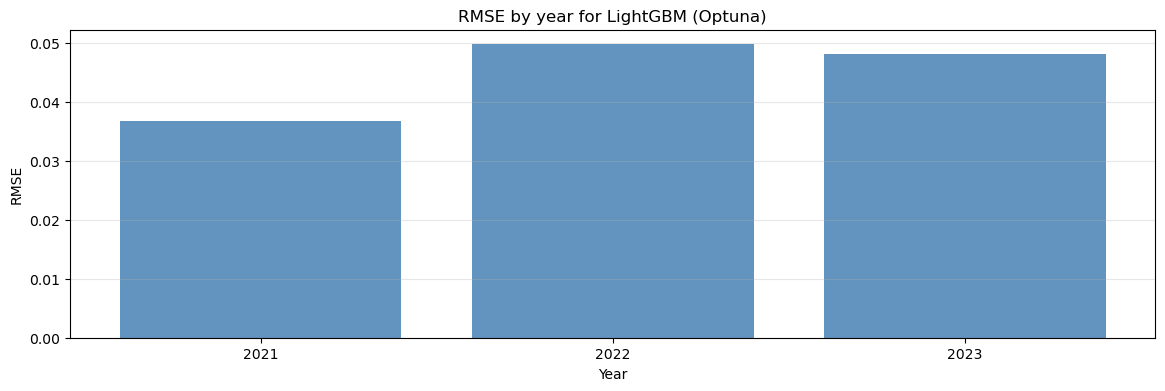

In [34]:
# MAPE and RMSE by calendar year

# prediction and year to the test rows
df_temporal = pd.DataFrame({
    "QUOTE_DATE": df_clean.loc[test_mask, "QUOTE_DATE"].values,
    "y_true": y_test.values,
    "y_pred": pipe_lgbm_tuned.predict(X_test),
})
df_temporal["year"] = df_temporal["QUOTE_DATE"].dt.year

yearly = (
    df_temporal.groupby("year").apply(lambda g: pd.Series({
        "RMSE": np.sqrt(mean_squared_error(g["y_true"], g["y_pred"])),
        "MAPE": mean_absolute_percentage_error(g["y_true"], g["y_pred"]) * 100,
        "R2": r2_score(g["y_true"], g["y_pred"]),
        "n": len(g),
    }))
    .reset_index()
)

print(yearly.round(4).to_string(index=False))

plt.figure(figsize=(14, 4))
plt.bar(yearly["year"].astype(str), yearly["RMSE"], color="steelblue", alpha=0.85)
plt.title("RMSE by year for LightGBM (Optuna)")
plt.xlabel("Year")
plt.ylabel("RMSE")
plt.grid(axis="y", alpha=0.3)
plt.show()


## Conclusion & Model Selection

| Model | Test RMSE | Test MAPE | Test R2 |
|-------|-----------|-----------|---------|
| OLS | 0.09334 | 791.80% | 0.87849|
| Ridge | 0.05676 | 1623.37% | 0.95507 |
| Random Forest |   0.05866 | 3327.24% | 0.95202 |
| LightGBM (default) | 0.04874 | 407.41% | 0.96688 |
| **LightGBM (Optuna)** | **0.04521** | **534.87%** | **0.97150** |


**Conclusion**: LightGBM (Optuna) offers the best test metrics across RMSE, MAPE and R2 with non-overlapping bootstrap confidence intervals.